In [115]:
import numpy as np
from evolml.models import *
from sklearn.linear_model import *
from sklearn.datasets import make_regression, load_diabetes, make_s_curve, make_swiss_roll
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, r2_score
import matplotlib.pyplot as plt

In [116]:
# X, y = load_diabetes(return_X_y=True)
# X, y = make_regression(1000, noise=50)
# X, y = make_s_curve(1000)
X, y = make_swiss_roll(5000)

print(X.shape)
print(y.shape)
# X, y = load_digits(return_X_y=True)
X_train_base, X_test_base, y_train, y_test = train_test_split(X, y, test_size=0.2)

X_scaler = MinMaxScaler()
# X_scaler = StandardScaler()
X_train = X_scaler.fit_transform(X_train_base)
X_test = X_scaler.transform(X_test_base)
print(X_train.min(), X_train.max())
print(X_test.min(), X_test.max())

(5000, 3)
(5000,)
0.0 1.0
-4.577788464965593e-08 0.9999822821009785


In [117]:
model = RBFNNRegressor(100, std_from_clusters=True)
# model = RBFNNRegressor(100, std_from_clusters=False)
# model = LinearRegression()
model = model.fit(X_train, y_train)
display(model)
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

/home/eugenio/anaconda3/envs/ml/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


RBFNNRegressor(cluster_model=KMeans(n_clusters=100),
               linear_layer=LinearRegression(), n_units=100,
               std_from_clusters=True)

0.9856282758724961
0.9834925390611229


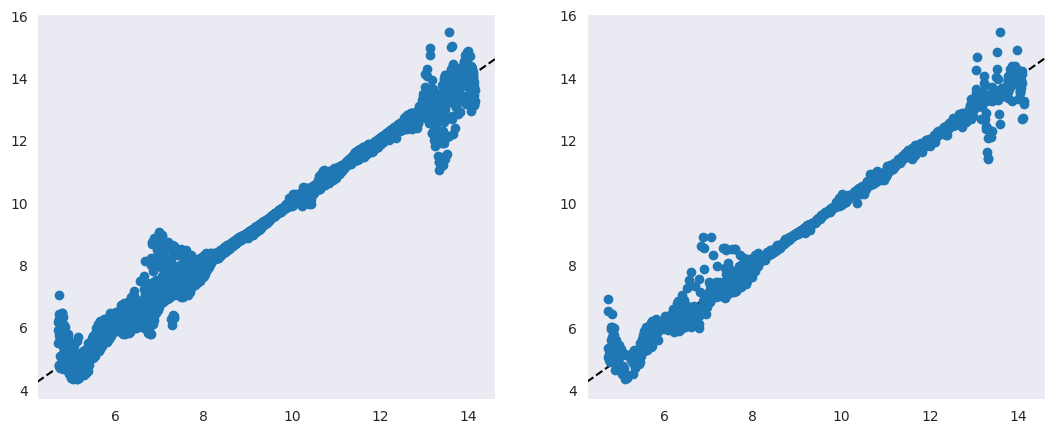

In [118]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].scatter(y_train, pred_train)
xlim = ax[0].get_xlim()
ax[0].set_xlim(xlim)
ax[0].plot(xlim, xlim, '--', color="black", zorder=-1)
print(r2_score(y_train, pred_train))

ax[1].scatter(y_test, pred_test)
xlim = ax[1].get_xlim()
ax[1].set_xlim(xlim)
ax[1].plot(xlim, xlim, '--', color="black", zorder=-1)
print(r2_score(y_test, pred_test))

plt.show()